Data Quality Checks

This notebook contains five data quality checks for the online retail dataset from Kaggle (https://www.kaggle.com/datasets/carrie1/ecommerce-data).
The main goal is to analyze the data and make sure it's valid, clean, and reliable enough for reporting and business analytics.

1. Data loading and setup

In [149]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [150]:
df = kagglehub.dataset_load(
      KaggleDatasetAdapter.PANDAS,
      "carrie1/ecommerce-data",
      file_path,
      pandas_kwargs={"encoding": "ISO-8859-1"}
)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset shape: 541,909 rows x 8 columns


2. Basic dataset structure

In [151]:
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [152]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [153]:
display(df.describe())

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [154]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

conn = sqlite3.connect(':memory:')
df.to_sql('ecommerce', conn, index=False, if_exists='replace')

541909

3. Data quality checks

Check 1: Missing customer IDs (Completeness)

This check verifies if all transactions have a CustomerID. 

Missing customer IDs usually indicate guest checkouts. Deleting these records would incorrectly lower the total revenue metrics, so it should only be treated as a warning. Setting a default value like "GUEST" would be a better approach for financial analysis. We'll use a simple "CustomerID IS NULL" SQL query to find them.

Records missing CustomerID: 135,080 (24.9%)


,InvoiceNo,StockCode,Description,CustomerID
0,536414,22139,NaN,None
1,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,None
2,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,None
3,536544,21786,POLKADOT RAIN HAT,None
4,536544,21787,RAIN PONCHO RETROSPOT,None


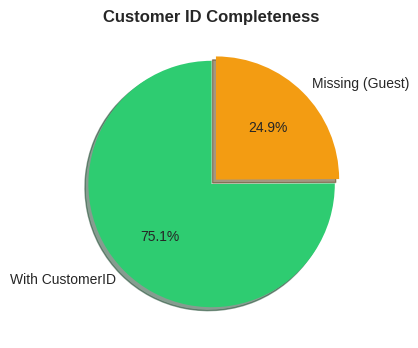

In [155]:
query_1 = """
SELECT 
    COUNT(*) as total_records,
    SUM(CASE WHEN CustomerID IS NULL THEN 1 ELSE 0 END) as missing_count
FROM ecommerce;
"""
stats_1 = pd.read_sql(query_1, conn)
missing_count = stats_1['missing_count'].iloc[0]
total_records = stats_1['total_records'].iloc[0]
missing_pct = (missing_count / total_records) * 100

print(f"Records missing CustomerID: {missing_count:,} ({missing_pct:.1f}%)")

query_1_sample = """
SELECT InvoiceNo, StockCode, Description, CustomerID
FROM ecommerce 
WHERE CustomerID IS NULL
LIMIT 5;
"""
display(pd.read_sql(query_1_sample, conn))

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie([total_records - missing_count, missing_count], 
       explode=(0, 0.05), labels=['With CustomerID', 'Missing (Guest)'], 
       colors=['#2ecc71', '#f39c12'], autopct='%1.1f%%', shadow=True, startangle=90)
ax.set_title('Customer ID Completeness', fontweight='bold')
plt.show()

Check 2: Invalid quantities and cancellations (Validity)

Here we look for mismatched signs between the quantity field and the cancellation flags. 

Normal returns have a 'C' prefix in the "InvoiceNo" and a negative "Quantity". A negative quantity without the 'C' prefix, or a positive quantity with a 'C' prefix, means there's a logic error in the data. This is a critical issue that messes up inventory and sales metrics. We'll use SQL to flag these specific anomalies.

Valid cancellations: 9,288
Logical data errors (mismatched flags): 1,336 (0.25%)


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
0,536589,21777,None,-10,0.0
1,536764,84952C,None,-38,0.0
2,536996,22712,None,-20,0.0
3,536997,22028,None,-20,0.0
4,536998,85067,None,-6,0.0


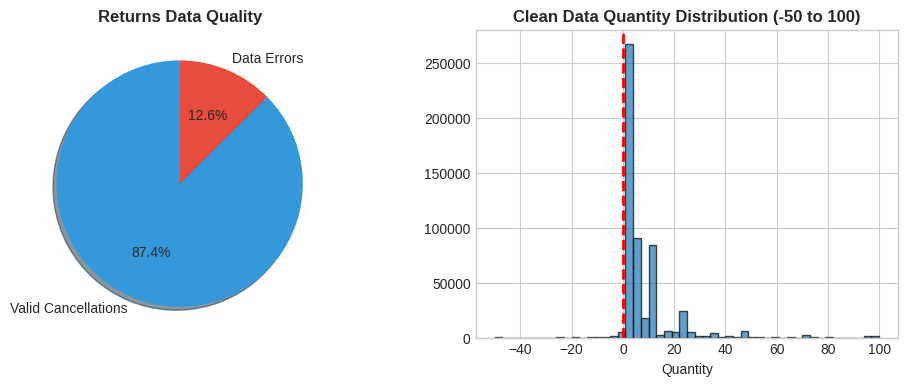

In [156]:
query_2_stats = """
SELECT 
    SUM(CASE WHEN Quantity <= 0 AND InvoiceNo LIKE 'C%' THEN 1 ELSE 0 END) as valid_cancellations,
    SUM(CASE WHEN Quantity > 0 AND InvoiceNo LIKE 'C%' THEN 1 ELSE 0 END) as invalid_cancellations,
    SUM(CASE WHEN Quantity < 0 AND InvoiceNo NOT LIKE 'C%' THEN 1 ELSE 0 END) as negative_no_c
FROM ecommerce;
"""
stats_2 = pd.read_sql(query_2_stats, conn)
valid_cancellations = stats_2['valid_cancellations'].iloc[0]
invalid_cancellations = stats_2['invalid_cancellations'].iloc[0]
negative_no_c = stats_2['negative_no_c'].iloc[0]
total_errors_qty = invalid_cancellations + negative_no_c

print(f"Valid cancellations: {valid_cancellations:,}")
print(f"Logical data errors (mismatched flags): {total_errors_qty:,} ({(total_errors_qty/total_records)*100:.2f}%)")

query_2_sample = """
SELECT InvoiceNo, StockCode, Description, Quantity, UnitPrice
FROM ecommerce 
WHERE (Quantity < 0 AND InvoiceNo NOT LIKE 'C%')
   OR (Quantity > 0 AND InvoiceNo LIKE 'C%')
LIMIT 5;
"""
display(pd.read_sql(query_2_sample, conn))


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if sum([valid_cancellations, total_errors_qty]) > 0:
    axes[0].pie([valid_cancellations, total_errors_qty], 
                labels=['Valid Cancellations', 'Data Errors'], 
                colors=['#3498db', '#e74c3c'], autopct='%1.1f%%', shadow=True, startangle=90)
axes[0].set_title('Returns Data Quality', fontweight='bold')

query_2_dist = """
SELECT Quantity 
FROM ecommerce 
WHERE NOT ((Quantity < 0 AND InvoiceNo NOT LIKE 'C%') OR (Quantity > 0 AND InvoiceNo LIKE 'C%'))
AND Quantity BETWEEN -50 AND 100;
"""
valid_qty = pd.read_sql(query_2_dist, conn)['Quantity']

axes[1].hist(valid_qty, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Quantity')
axes[1].set_title('Clean Data Quantity Distribution (-50 to 100)', fontweight='bold')
plt.show()

Check 3: Duplicate records (Uniqueness)

We also need to ensure there are no exact duplicate rows. Duplicate transactions inflate sales figures and cause errors in KPIs. It's a critical issue, and any identical rows should ideally be handled and deduplicated before loading the data into our data warehouse.

Exact duplicate records found: 5,268 (0.97%)


,InvoiceNo,StockCode,Quantity,UnitPrice,occurrence_count
0,555524,22698,1,2.95,20
1,555524,22697,1,2.95,12
2,572861,22775,12,1.25,8
3,538514,21756,1,5.95,6
4,540524,21756,1,5.95,6


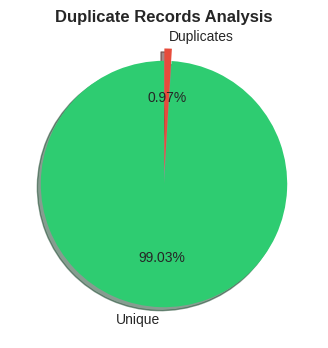

In [157]:
query_3_stats = """
SELECT SUM(occurrence_count - 1) as total_duplicates
FROM (
    SELECT COUNT(*) as occurrence_count
    FROM ecommerce
    GROUP BY InvoiceNo, StockCode, Description, Quantity, UnitPrice, InvoiceDate, CustomerID, Country
    HAVING COUNT(*) > 1
);
"""
total_duplicates = pd.read_sql(query_3_stats, conn)['total_duplicates'].iloc[0]
if pd.isna(total_duplicates):
    total_duplicates = 0
else:
    total_duplicates = int(total_duplicates)
    
duplicate_pct = (total_duplicates / total_records) * 100

print(f"Exact duplicate records found: {total_duplicates:,} ({duplicate_pct:.2f}%)")

query_3_sample = """
SELECT InvoiceNo, StockCode, Quantity, UnitPrice, COUNT(*) as occurrence_count
FROM ecommerce
GROUP BY InvoiceNo, StockCode, Description, Quantity, UnitPrice, InvoiceDate, CustomerID, Country
HAVING COUNT(*) > 1
ORDER BY occurrence_count DESC
LIMIT 5;
"""
display(pd.read_sql(query_3_sample, conn))

fig, ax = plt.subplots(figsize=(6, 4))
if total_duplicates > 0:
    ax.pie([total_records - total_duplicates, total_duplicates], 
           explode=(0, 0.1), labels=['Unique', 'Duplicates'], 
           colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%', shadow=True, startangle=90)
    ax.set_title('Duplicate Records Analysis', fontweight='bold')
plt.show()

Check 4: Zero or negative prices (Accuracy)

This checks if there are any products with "UnitPrice <= 0". Negative prices are almost certainly system errors, while a zero price could just be a promotional gift, discount, or a system event (like a 'MANUAL' adjustment). So, we treat this as a warning rather than a critical failure, since zero prices aren't always bad data.

Zero price records (promos/system adjustments): 2,515
Negative price records (errors): 2


,InvoiceNo,StockCode,Description,UnitPrice,Quantity
0,536414,22139,None,0.0,56
1,536545,21134,None,0.0,1
2,536546,22145,None,0.0,1
3,536547,37509,None,0.0,1
4,536549,85226A,None,0.0,1


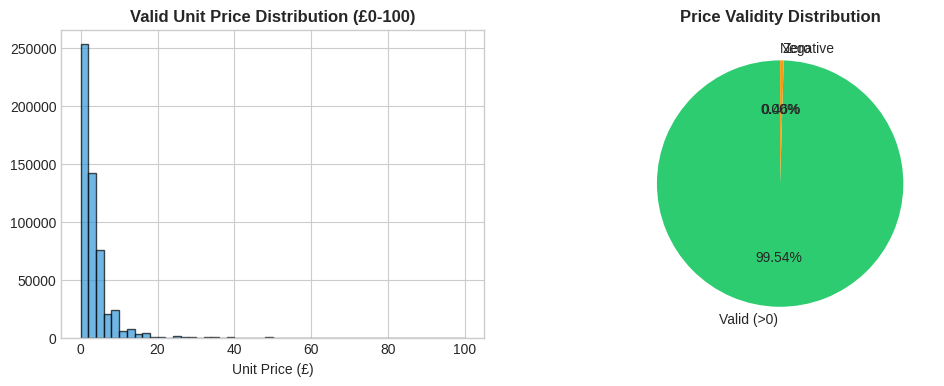

In [158]:
query_4 = """
SELECT InvoiceNo, StockCode, Description, UnitPrice, Quantity
FROM ecommerce
WHERE UnitPrice <= 0
LIMIT 5;
"""
display(pd.read_sql(query_4, conn))

zero_price_count = len(df[df['UnitPrice'] == 0])
negative_price_count = len(df[df['UnitPrice'] < 0])
total_problematic = zero_price_count + negative_price_count

print(f"Zero price records (promos/system adjustments): {zero_price_count:,}")
print(f"Negative price records (errors): {negative_price_count:,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
valid_prices = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] <= 100)]['UnitPrice']
axes[0].hist(valid_prices, bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[0].set_xlabel('Unit Price (£)')
axes[0].set_title('Valid Unit Price Distribution (£0-100)', fontweight='bold')

if total_problematic > 0:
    axes[1].pie([len(df) - total_problematic, zero_price_count, negative_price_count], 
                labels=['Valid (>0)', 'Zero', 'Negative'], 
                colors=['#2ecc71', '#f39c12', '#e74c3c'], autopct='%1.2f%%', startangle=90)
    axes[1].set_title('Price Validity Distribution', fontweight='bold')
plt.show()

Check 5: Date anomalies (Timeliness)

We're checking if the invoice dates fall within a reasonable timeline. We'll verify that dates aren't from the future (`> CURRENT_TIMESTAMP`) or completely unreasonable past system defaults (`< 2000-01-01`).

Dataset Timeline: 2010-12-01 to 2011-12-09
Records outside logical timeline (2000-01-01 to NOW): 0


,InvoiceNo,InvoiceDate,CustomerID,Country


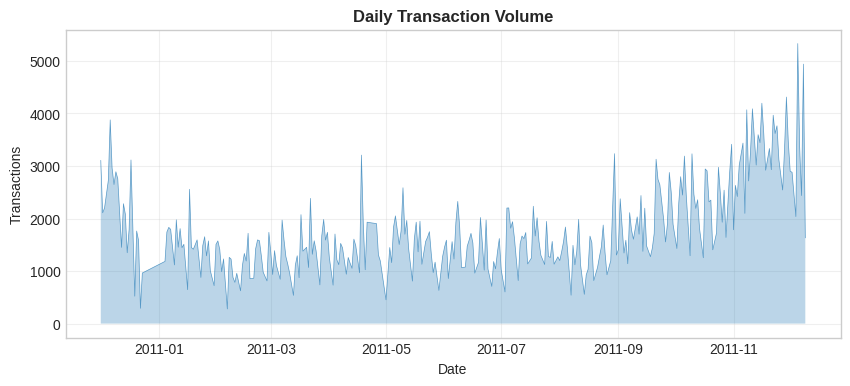

In [159]:
query_5_stats = """
SELECT 
    SUM(CASE WHEN date(InvoiceDate) < '2000-01-01' THEN 1 ELSE 0 END) as before_range_count,
    SUM(CASE WHEN InvoiceDate > CURRENT_TIMESTAMP THEN 1 ELSE 0 END) as after_range_count,
    MIN(date(InvoiceDate)) as min_date,
    MAX(date(InvoiceDate)) as max_date
FROM ecommerce;
"""
stats_5 = pd.read_sql(query_5_stats, conn)
before_range_count = int(stats_5['before_range_count'].iloc[0])
after_range_count = int(stats_5['after_range_count'].iloc[0])
out_of_range = before_range_count + after_range_count

print(f"Dataset Timeline: {stats_5['min_date'].iloc[0]} to {stats_5['max_date'].iloc[0]}")
print(f"Records outside logical timeline (2000-01-01 to NOW): {out_of_range:,}")

query_5_sample = """
SELECT InvoiceNo, InvoiceDate, CustomerID, Country
FROM ecommerce
WHERE date(InvoiceDate) < '2000-01-01' OR InvoiceDate > CURRENT_TIMESTAMP
LIMIT 5;
"""
display(pd.read_sql(query_5_sample, conn))

fig, ax = plt.subplots(figsize=(10, 4))
query_5_dist = """
SELECT date(InvoiceDate) as dt, COUNT(*) as daily_counts
FROM ecommerce
GROUP BY date(InvoiceDate)
ORDER BY dt;
"""
daily_counts_df = pd.read_sql(query_5_dist, conn)
daily_counts_df['dt'] = pd.to_datetime(daily_counts_df['dt'])

ax.plot(daily_counts_df['dt'], daily_counts_df['daily_counts'], linewidth=0.5, alpha=0.7)
ax.fill_between(daily_counts_df['dt'], 0, daily_counts_df['daily_counts'], alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Transactions')
ax.set_title('Daily Transaction Volume', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.show()

### Summary

,Check Name,What it verifies,Data Quality Dimension,SQL Logic / Condition,Severity Level,Anomalies Found,% of Total
0,Customer ID Completeness,Ensures all transactions have a valid CustomerID assigned,Completeness,CustomerID IS NULL,Warning,135080,24.93%
1,Invalid Quantity/Cancellations,Detects mismatched signs between quantity field and cancellation flags,Validity,(Quantity < 0 AND InvoiceNo NOT LIKE 'C%') OR (Quantity > 0 AND InvoiceNo LIKE 'C%'),Critical,1336,0.25%
2,Duplicate Invoice Lines,Ensures there are no exact duplicate rows across all columns,Uniqueness,HAVING COUNT(*) > 1 (GROUP BY all columns),Critical,5268,0.97%
3,Zero Unit Price,Checks if there are any products with zero UnitPrice (e.g. promos),Accuracy,UnitPrice = 0,Warning,2515,0.46%
4,Negative Unit Price,Checks if there are any products with negative UnitPrice (errors),Accuracy,UnitPrice < 0,Critical,2,0.0%
5,Timeliness and Expected Dates,Checks if invoice dates fall within a logical timeline,Timeliness,date(InvoiceDate) < '2000-01-01' OR InvoiceDate > CURRENT_TIMESTAMP,Warning,0,0.0%


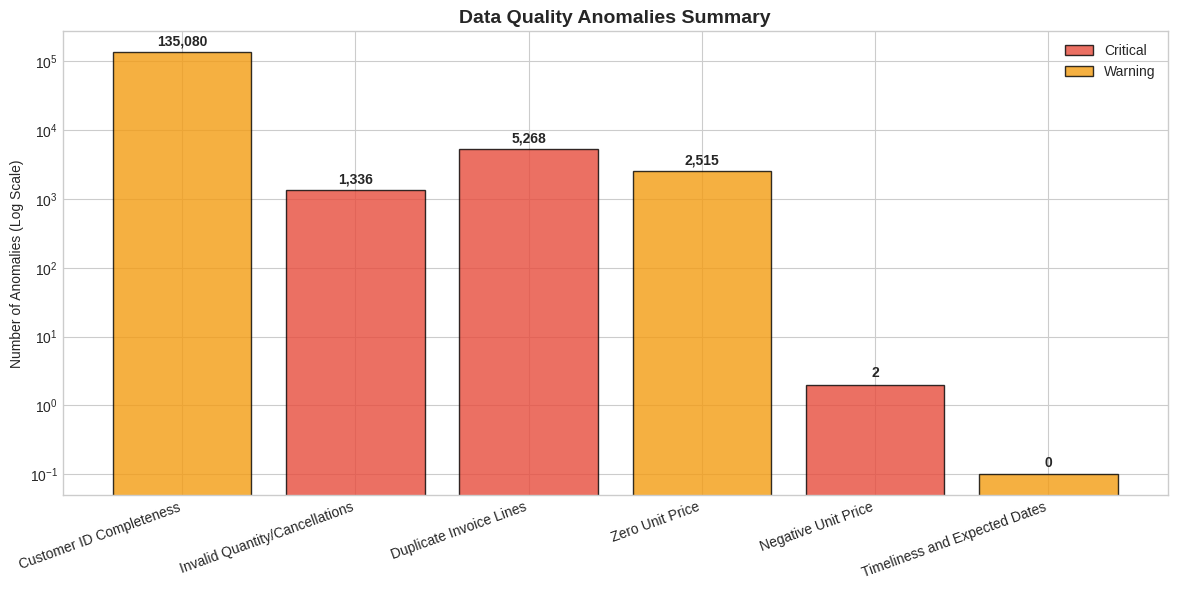

In [160]:
summary_data = {
    'Check Name': [
        'Customer ID Completeness', 
        'Invalid Quantity/Cancellations', 
        'Duplicate Invoice Lines', 
        'Zero Unit Price', 
        'Negative Unit Price',
        'Timeliness and Expected Dates'
    ],
    'What it verifies': [
        'Ensures all transactions have a valid CustomerID assigned',
        'Detects mismatched signs between quantity field and cancellation flags',
        'Ensures there are no exact duplicate rows across all columns',
        'Checks if there are any products with zero UnitPrice (e.g. promos)',
        'Checks if there are any products with negative UnitPrice (errors)',
        'Checks if invoice dates fall within a logical timeline'
    ],
    'Data Quality Dimension': [
        'Completeness', 
        'Validity', 
        'Uniqueness', 
        'Accuracy', 
        'Accuracy',
        'Timeliness'
    ],
    'SQL Logic / Condition': [
        'CustomerID IS NULL',
        "(Quantity < 0 AND InvoiceNo NOT LIKE 'C%') OR (Quantity > 0 AND InvoiceNo LIKE 'C%')",
        'HAVING COUNT(*) > 1 (GROUP BY all columns)',
        'UnitPrice = 0',
        'UnitPrice < 0',
        "date(InvoiceDate) < '2000-01-01' OR InvoiceDate > CURRENT_TIMESTAMP"
    ],
    'Severity Level': ['Warning', 'Critical', 'Critical', 'Warning', 'Critical', 'Warning'],
    'Anomalies Found': [
        missing_count, total_errors_qty, total_duplicates, 
        zero_price_count, negative_price_count, out_of_range
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['% of Total'] = (summary_df['Anomalies Found'] / total_records * 100).round(2).astype(str) + '%'

display(summary_df.style.set_properties(**{'text-align': 'left'}))

fig, ax = plt.subplots(figsize=(12, 6))
display_counts = [c if c > 0 else 0.1 for c in summary_df['Anomalies Found']]

# Define colors based on severity
colors = ['#e74c3c' if s == 'Critical' else '#f39c12' for s in summary_df['Severity Level']]

bars = ax.bar(summary_df['Check Name'], display_counts, 
              color=colors, edgecolor='black', alpha=0.8)

# Add value labels on top of the bars
for bar, count in zip(bars, summary_df['Anomalies Found']):
    if count > 0:
        ax.annotate(f'{int(count):,}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:
        # Display 0 explicitly if count is 0
        ax.annotate('0', xy=(bar.get_x() + bar.get_width() / 2, 0.1),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_yscale('log')
ax.set_ylabel('Number of Anomalies (Log Scale)')
ax.set_title('Data Quality Anomalies Summary', fontsize=14, fontweight='bold')

# Create legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', edgecolor='black', alpha=0.8, label='Critical'),
    Patch(facecolor='#f39c12', edgecolor='black', alpha=0.8, label='Warning')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [161]:
conn.close()